In [1]:
# [setup]
# July 2026 marketing-lift walkthrough. Visualizes the bidirectional `m`
# adjustment on Fenix Android (country=ALL), where the applied lift == the full
# daily lift series. Four core plots + a KPI sniff-test panel vs June.
import glob
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path('/Users/brendanwells/work/mozaic-daily')
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
TRAINING_END = pd.Timestamp('2026-06-28')
EOY = pd.Timestamp('2026-12-31')
PLOT_START = pd.Timestamp('2026-01-01')

# --- Marketing-team CSV (July) ---
CSV = REPO / 'data-official/2026-07/marketing/source_data/paid_dau_from_uac_campaigns.20260629.csv'
csv = pd.read_csv(CSV, thousands=',')
_wk = csv['week'].str.extract(r'(\d+)')[0].astype(int)
csv['date'] = pd.Timestamp('2026-01-05') + pd.to_timedelta((_wk - 1) * 7, unit='D')
csv = csv.set_index('date')
CSV_ACTUAL_END = pd.Timestamp('2026-01-05') + pd.to_timedelta((26 - 1) * 7, unit='D')  # Week 26 = last actual

# --- Applied lift series (June-anchored) + June reference ---
JULY_LIFT = REPO / 'data-official/2026-07/marketing/marketing_lift_model.june_anchored.2026-06-29.parquet'
JUNE_LIFT = REPO / 'data-official/2026-06/marketing/marketing_lift_model.real_data_v2.hybrid.2026-05-22.parquet'
def _lift(p):
    s = pd.read_parquet(p)['marketing_lift_daily'].copy()
    s.index = pd.DatetimeIndex(s.index).normalize()
    return s.sort_index()
lift = _lift(JULY_LIFT)          # L(d) applied this cycle
june_lift = _lift(JUNE_LIFT)

# --- Forecast runs (no-marketing base run + with-marketing trial) ---
NOMKTG = sorted(glob.glob(str(REPO / 'tmp/no_mktg_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0]
WITHMKTG = sorted(glob.glob(str(REPO / 'tmp/with_mktg_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0]
def _load(p):
    d = pd.read_parquet(p); d['target_date'] = pd.to_datetime(d['target_date']); return d
nomk = _load(NOMKTG)
wmk = _load(WITHMKTG)

def series(df, app_name, dt=None, country='ALL', excl_ir=False):
    """DAU series for glean_mobile / country / app, optionally filtered by data_type."""
    def pick(c):
        s = df[(df.data_source == 'glean_mobile') & (df.country == c)
               & (df.app_name == app_name) & (df.segment == '{}')]
        if dt is not None:
            s = s[s.data_type == dt]
        return s.set_index('target_date').sort_index()['dau']
    base = pick(country)
    if excl_ir and country == 'ALL':
        base = base.subtract(pick('IR'), fill_value=0.0)
    return base

def ma28(s):
    return s.rolling(28, min_periods=14).mean()

# Fenix Android ALL: actuals (real telemetry), and the applied lift aligned to it.
fenix_actuals = series(nomk, 'fenix_android', dt='training')         # true telemetry (no subtraction in this run)
fenix_fc_withmktg = series(wmk, 'fenix_android', dt='forecast')      # base + L
L_fc = lift.reindex(fenix_fc_withmktg.index).fillna(0.0)
fenix_fc_base = fenix_fc_withmktg - L_fc                             # de-marketed base (approx; add-back not strictly tight)
L_hist = lift.reindex(fenix_actuals.index).fillna(0.0)

APP_ALL = 'ALL MOBILE'
print('apps in with-mktg run:', sorted(wmk[wmk.data_source == 'glean_mobile'].app_name.unique()))
print(f'Fenix ALL actuals through {fenix_actuals.dropna().index.max().date()}: {fenix_actuals.dropna().iloc[-1]:,.0f}')
print(f'Applied lift  training_end={lift.loc[TRAINING_END]:>+,.0f}   EOY={lift.loc[EOY]:>+,.0f}')
print(f'June lift     EOY={june_lift.loc[EOY]:>+,.0f}   (delta = {lift.loc[EOY]-june_lift.loc[EOY]:>+,.0f})')


apps in with-mktg run: ['ALL MOBILE', 'fenix_android', 'firefox_ios', 'focus_android', 'focus_ios']
Fenix ALL actuals through 2026-06-28: 12,662,693
Applied lift  training_end=+726,490   EOY=+784,476
June lift     EOY=+645,479   (delta = +138,997)


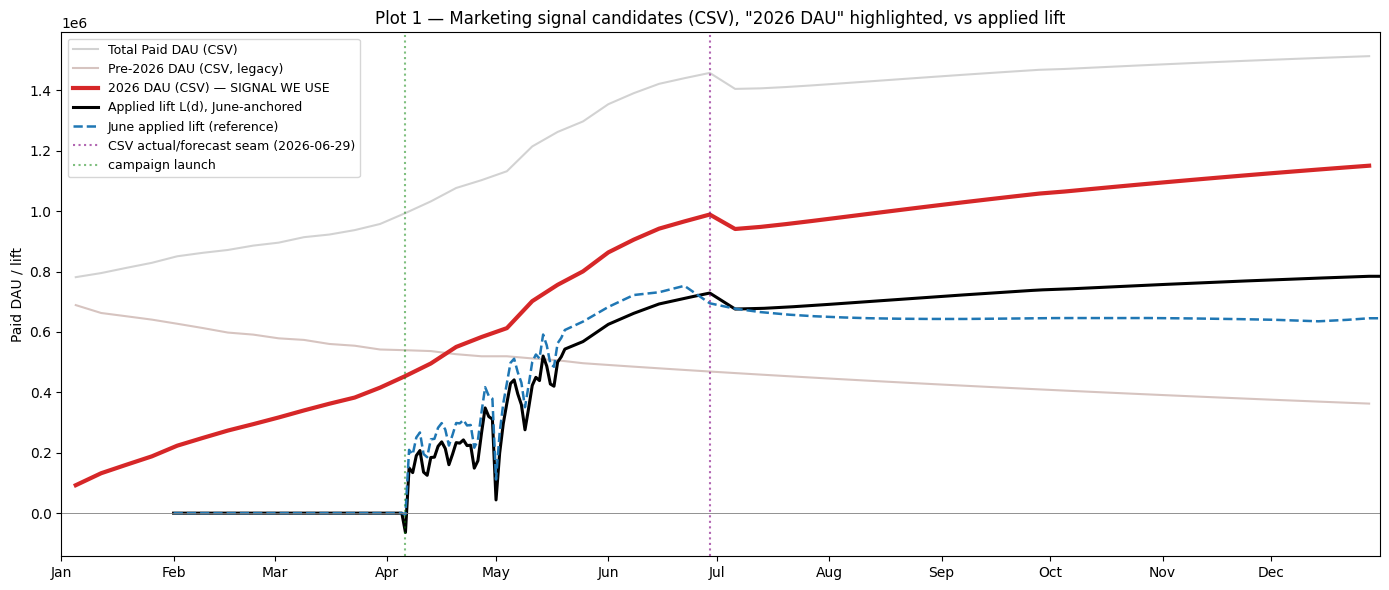

In [2]:
# [plot1-marketing-columns]
# The marketing-team CSV's paid-DAU columns. The column we use as the marketing
# signal — "2026 DAU" (the 2026 acquisition cohort) — is highlighted; the others
# are faded. Overlaid: the applied lift L(d) (June-anchored) and June's lift.
fig, ax = plt.subplots(figsize=(14, 6))
faded = dict(alpha=0.35, linewidth=1.5)
ax.plot(csv.index, csv['Total Paid DAU'], color='grey', label='Total Paid DAU (CSV)', **faded)
ax.plot(csv.index, csv['Pre-2026 DAU'], color='tab:brown', label='Pre-2026 DAU (CSV, legacy)', **faded)
ax.plot(csv.index, csv['2026 DAU'], color='tab:red', linewidth=3.0,
        label='2026 DAU (CSV) — SIGNAL WE USE')
ax.plot(lift.index, lift, color='black', linewidth=2.2, linestyle='-',
        label='Applied lift L(d), June-anchored')
ax.plot(june_lift.index, june_lift, color='tab:blue', linewidth=1.8, linestyle='--',
        label='June applied lift (reference)')
ax.axvline(CSV_ACTUAL_END, color='purple', linestyle=':', alpha=0.6,
           label=f'CSV actual/forecast seam ({CSV_ACTUAL_END.date()})')
ax.axvline(CAMPAIGN_LAUNCH, color='green', linestyle=':', alpha=0.5, label='campaign launch')
ax.axhline(0, color='grey', linewidth=0.6)
ax.set_title('Plot 1 — Marketing signal candidates (CSV), "2026 DAU" highlighted, vs applied lift')
ax.set_ylabel('Paid DAU / lift')
ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()


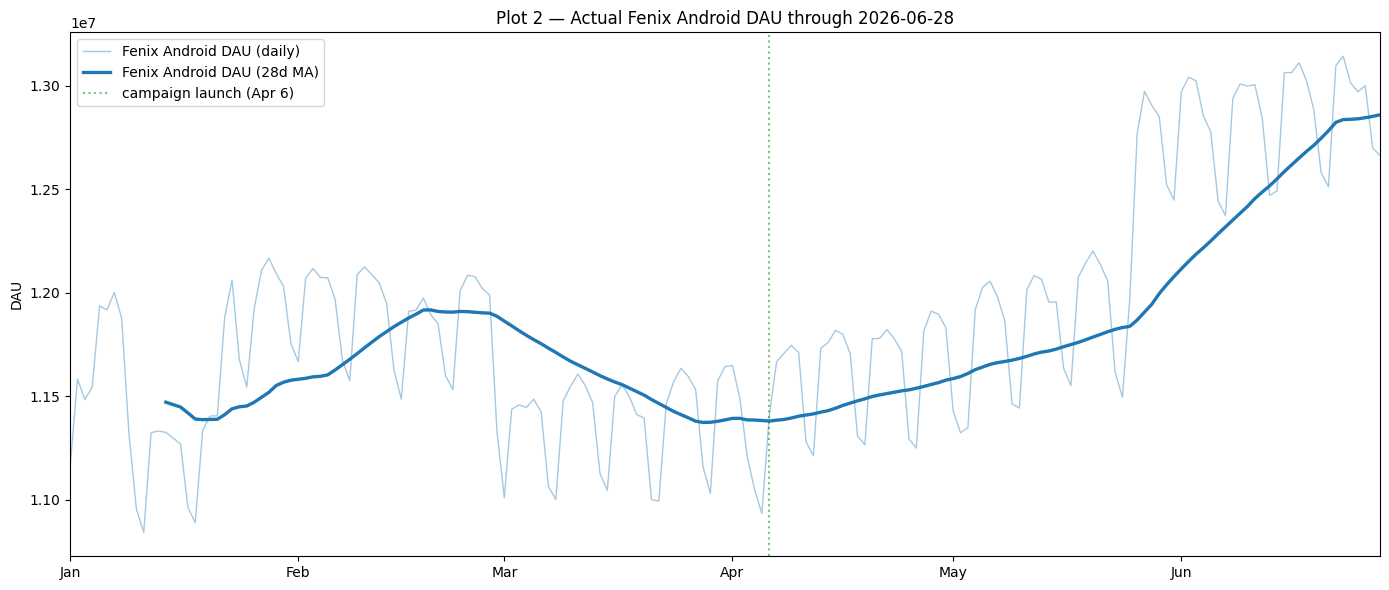

In [3]:
# [plot2-actuals]
# The actual data up till now: Fenix Android (country=ALL) DAU through the
# training end (2026-06-28). Daily + 28-day moving average.
fig, ax = plt.subplots(figsize=(14, 6))
hist = fenix_actuals.loc[PLOT_START:TRAINING_END]
ax.plot(hist.index, hist, color='tab:blue', alpha=0.4, linewidth=1.0, label='Fenix Android DAU (daily)')
ax.plot(hist.index, ma28(hist), color='tab:blue', linewidth=2.4, label='Fenix Android DAU (28d MA)')
ax.axvline(CAMPAIGN_LAUNCH, color='green', linestyle=':', alpha=0.5, label='campaign launch (Apr 6)')
ax.set_title('Plot 2 — Actual Fenix Android DAU through 2026-06-28')
ax.set_ylabel('DAU'); ax.set_xlim(PLOT_START, TRAINING_END)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()


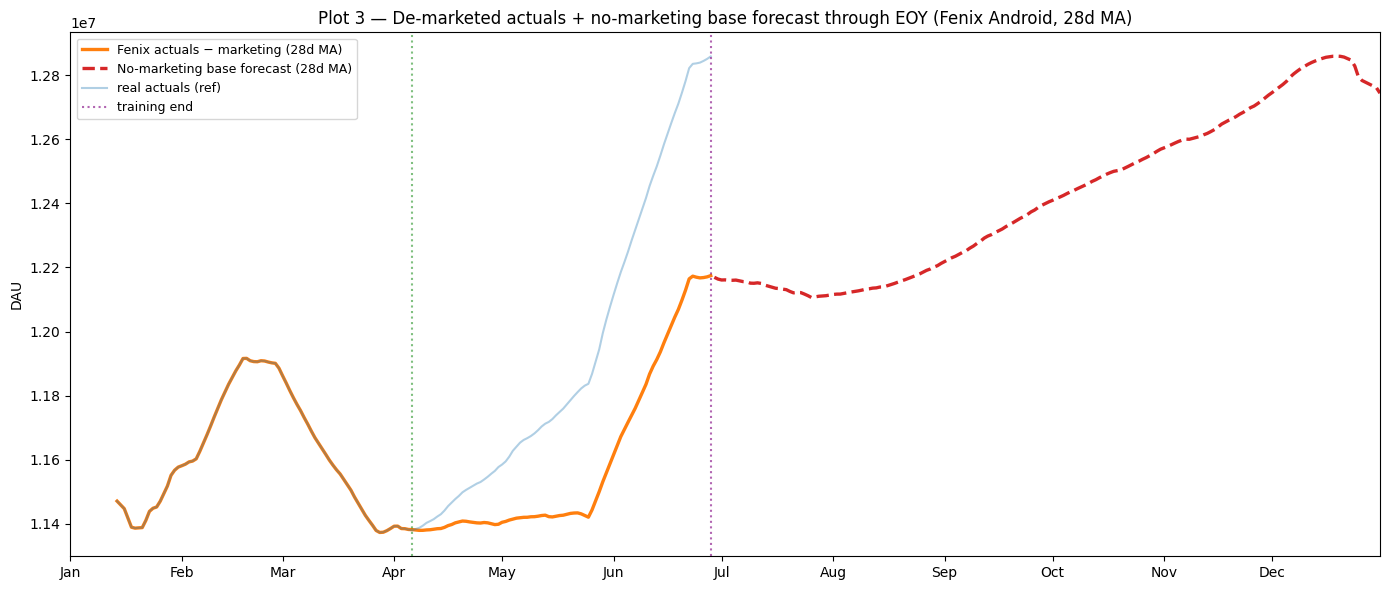

In [4]:
# [plot3-demarketed-plus-forecast]
# Actual data with the marketing contribution SUBTRACTED, plus the no-marketing
# base forecast through EOY. This is what Prophet/mozaic sees and projects once
# the campaign lift is removed from training (the pre-mozaic subtraction step).
demk_hist = (fenix_actuals - L_hist).loc[PLOT_START:TRAINING_END]

fig, ax = plt.subplots(figsize=(14, 6))
# de-marketed history
ax.plot(demk_hist.index, ma28(demk_hist), color='tab:orange', linewidth=2.4,
        label='Fenix actuals − marketing (28d MA)')
# base forecast through EOY
base_fc = fenix_fc_base.loc[:EOY]
ax.plot(base_fc.index, ma28(pd.concat([demk_hist, base_fc]).sort_index()).loc[base_fc.index],
        color='tab:red', linewidth=2.4, linestyle='--', label='No-marketing base forecast (28d MA)')
# faint real actuals MA for reference
ax.plot(fenix_actuals.loc[PLOT_START:TRAINING_END].index,
        ma28(fenix_actuals.loc[PLOT_START:TRAINING_END]),
        color='tab:blue', alpha=0.35, linewidth=1.5, label='real actuals (ref)')
ax.axvline(TRAINING_END, color='purple', linestyle=':', alpha=0.6, label='training end')
ax.axvline(CAMPAIGN_LAUNCH, color='green', linestyle=':', alpha=0.5)
ax.set_title('Plot 3 — De-marketed actuals + no-marketing base forecast through EOY (Fenix Android, 28d MA)')
ax.set_ylabel('DAU'); ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()


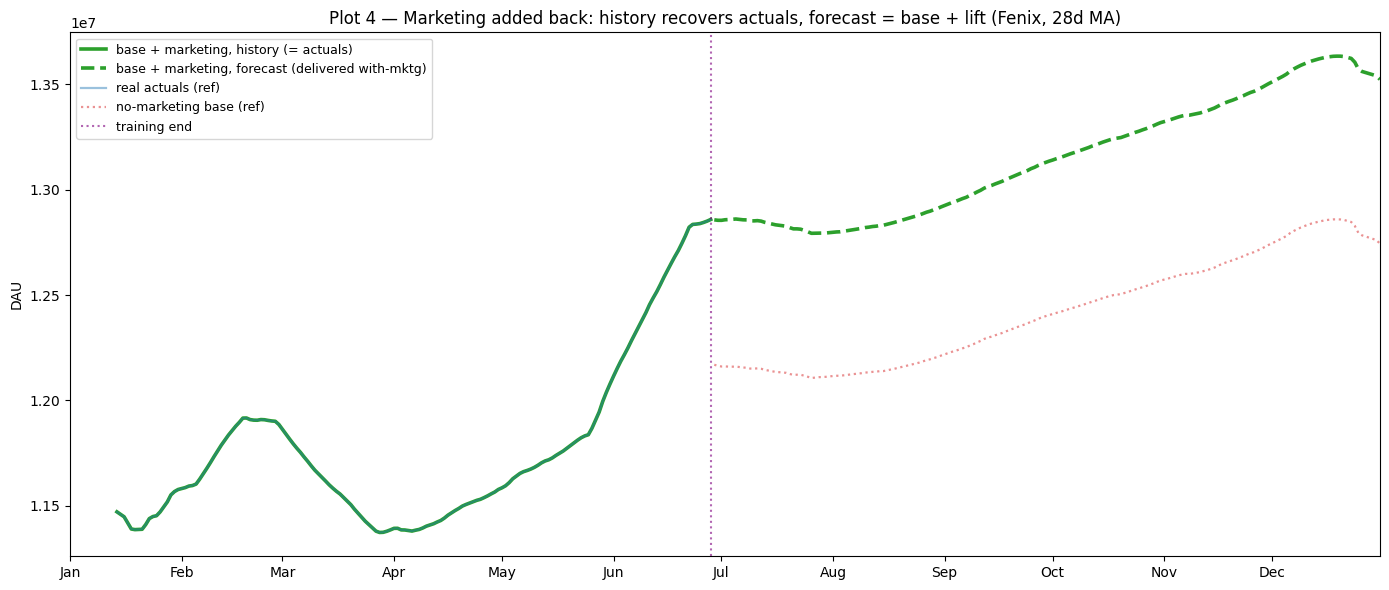

In [5]:
# [plot4-addback]
# The de-marketed base (Plot 3) with the marketing contribution ADDED BACK IN
# (post-mozaic add-back step). Historically this recovers the real actuals
# (subtract-then-add is identity); in the forecast it is base + L(d) = the
# delivered with-marketing curve.
demk_hist = (fenix_actuals - L_hist).loc[PLOT_START:TRAINING_END]
addback_hist = demk_hist + L_hist.loc[demk_hist.index]           # == real actuals
final_fc = fenix_fc_withmktg.loc[:EOY]                            # base + L

full = pd.concat([addback_hist, final_fc]).sort_index()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(addback_hist.index, ma28(full).loc[addback_hist.index], color='tab:green', linewidth=2.6,
        label='base + marketing, history (= actuals)')
ax.plot(final_fc.index, ma28(full).loc[final_fc.index], color='tab:green', linewidth=2.6, linestyle='--',
        label='base + marketing, forecast (delivered with-mktg)')
# reference lines
ax.plot(fenix_actuals.loc[PLOT_START:TRAINING_END].index,
        ma28(fenix_actuals.loc[PLOT_START:TRAINING_END]),
        color='tab:blue', alpha=0.45, linewidth=1.6, label='real actuals (ref)')
ax.plot(fenix_fc_base.loc[:EOY].index,
        ma28(pd.concat([demk_hist, fenix_fc_base.loc[:EOY]]).sort_index()).loc[fenix_fc_base.loc[:EOY].index],
        color='tab:red', alpha=0.5, linewidth=1.6, linestyle=':', label='no-marketing base (ref)')
ax.axvline(TRAINING_END, color='purple', linestyle=':', alpha=0.6, label='training end')
ax.set_title('Plot 4 — Marketing added back: history recovers actuals, forecast = base + lift (Fenix, 28d MA)')
ax.set_ylabel('DAU'); ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()


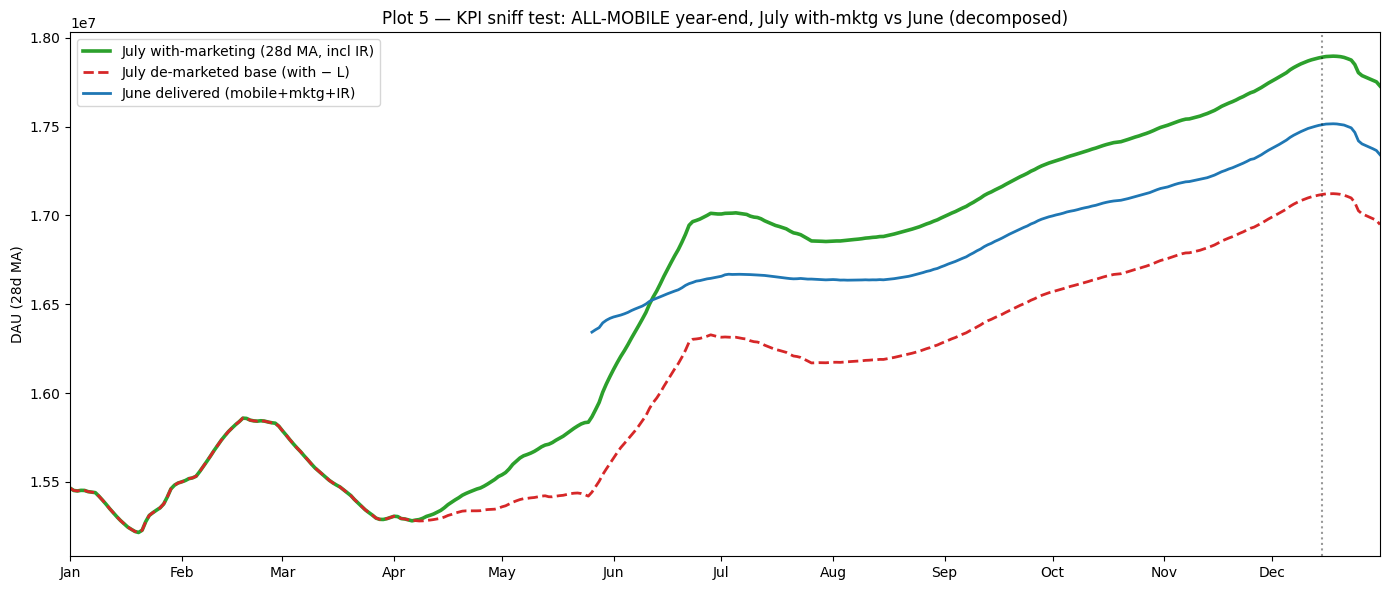

Dec-15 ALL-MOBILE (28d MA, incl Iran):
  July with-marketing :     17,891,074
  June delivered      :     17,511,100
  TOTAL July − June   :       +379,974
  --- decomposition ---
  marketing  (L_jul 778,880 − L_jun 635,995) :     +142,885   [matches CSV outlook delta ~+139k]
  base drift (base_jul − base_jun)          :     +237,090   [Iran native vs synthetic + fresher data]


In [6]:
# [plot5-kpi-sniff-test]
# Sniff test (your gate): ALL-MOBILE (country=ALL, incl Iran, 28d MA) year-end
# KPI. July with-marketing vs June's delivered curve, DECOMPOSED into the
# marketing component (the applied lift L) and non-marketing base drift.
#
# NOTE: the no-marketing *run* is NOT a valid baseline — it leaves the campaign
# in training and extrapolates it. The correct no-marketing base is
# (with-marketing forecast − L), i.e. what mozaic learned on de-marketed data.
jc = pd.read_csv(REPO / 'data-official/2026-06/csv/june_canonical_curves.csv',
                 parse_dates=['date']).set_index('date')
june_kpi = jc['mobile_current_june_plus_iran']

mob_wi = ma28(series(wmk, APP_ALL, dt=None, country='ALL'))          # July with-mktg
L_all = lift.reindex(series(wmk, APP_ALL, dt=None, country='ALL').index).fillna(0.0)
mob_base = ma28(series(wmk, APP_ALL, dt=None, country='ALL') - L_all)  # July de-marketed base

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(mob_wi.loc[PLOT_START:EOY].index, mob_wi.loc[PLOT_START:EOY],
        color='tab:green', linewidth=2.6, label='July with-marketing (28d MA, incl IR)')
ax.plot(mob_base.loc[PLOT_START:EOY].index, mob_base.loc[PLOT_START:EOY],
        color='tab:red', linewidth=2.0, linestyle='--', label='July de-marketed base (with − L)')
ax.plot(june_kpi.loc[PLOT_START:EOY].index, june_kpi.loc[PLOT_START:EOY],
        color='tab:blue', linewidth=2.0, label='June delivered (mobile+mktg+IR)')
ax.axvline(pd.Timestamp('2026-12-15'), color='black', linestyle=':', alpha=0.4)
ax.set_title('Plot 5 — KPI sniff test: ALL-MOBILE year-end, July with-mktg vs June (decomposed)')
ax.set_ylabel('DAU (28d MA)'); ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()

d15 = pd.Timestamp('2026-12-15')
jw, jj = mob_wi.loc[d15], june_kpi.loc[d15]
L_jul, L_jun = lift.loc[d15], june_lift.loc[d15]
base_jul, base_jun = jw - L_jul, jj - L_jun
print('Dec-15 ALL-MOBILE (28d MA, incl Iran):')
print(f'  July with-marketing : {jw:>14,.0f}')
print(f'  June delivered      : {jj:>14,.0f}')
print(f'  TOTAL July − June   : {jw-jj:>+14,.0f}')
print( '  --- decomposition ---')
print(f'  marketing  (L_jul {L_jul:,.0f} − L_jun {L_jun:,.0f}) : {L_jul-L_jun:>+12,.0f}   [matches CSV outlook delta ~+139k]')
print(f'  base drift (base_jul − base_jun)          : {base_jul-base_jun:>+12,.0f}   [Iran native vs synthetic + fresher data]')


In [7]:
# [s2-setup]
# ============================================================================
# SECTION 2 — Two-curve comparison: 2026-only cohort vs Total Paid DAU
# Full procedure (subtract -> forecast -> add) for BOTH lift curves, level-set
# at the most recent actual day (2026-06-28) using the June-canonical display_ma
# seam-smoothing. Everything here is the "July" forecast.
# ============================================================================
FORECAST_START_S2 = pd.Timestamp('2026-06-29')
SEAM = pd.Timestamp('2026-06-28')           # most recent actual day = level-set point

# --- canonical display_ma (copied verbatim from data-official/2026-06/export_canonical_curves.py) ---
def daily_to_28ma(dates, values):
    s = pd.Series(np.asarray(values), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()

def reconstruct_matched_daily(pre, fc, forecast_start, window=28):
    trend_fc = fc.rolling(7, center=True, min_periods=4).mean()
    recent = pre[pre.index >= forecast_start - pd.Timedelta(weeks=13)]
    recent_trend = recent.rolling(7, center=True, min_periods=4).mean()
    ratio = (recent / recent_trend).replace([np.inf, -np.inf], np.nan).dropna()
    dow_act = ratio.groupby(ratio.index.dayofweek).mean()
    dow_act = dow_act / dow_act.mean()
    dow_act = dow_act.reindex(range(7)).fillna(1.0)
    return trend_fc * dow_act.reindex(fc.index.dayofweek).to_numpy()

def display_ma(dates, values, forecast_start, window=28):
    s = pd.Series(np.asarray(values), index=pd.to_datetime(np.asarray(dates))).sort_index()
    first_clean = forecast_start + pd.Timedelta(days=window - 1)
    pre, fc = s[s.index < forecast_start], s[s.index >= forecast_start]
    forecast_only_ma = fc.rolling(window).mean()
    result = s.rolling(window).mean()
    if forecast_start in s.index and first_clean in forecast_only_ma.index:
        matched = reconstruct_matched_daily(pre, fc, forecast_start, window)
        transition_ma = pd.concat([pre, matched]).sort_index().rolling(window).mean()
        result.loc[forecast_only_ma.index] = forecast_only_ma
        mask = (result.index >= forecast_start) & (result.index < first_clean)
        result.loc[mask] = transition_ma.reindex(result.index)[mask]
    return result

# --- load the two runs + their lift series ---
RUNS = {
    'total':      REPO / 'tmp/mktg_total_2026-06-29',
    'cohort2026': REPO / 'tmp/mktg_2026_2026-06-29',
}
LIFTS = {
    'total':      REPO / 'data-official/2026-07/marketing/marketing_lift_model.total.2026-06-29.parquet',
    'cohort2026': REPO / 'data-official/2026-07/marketing/marketing_lift_model.cohort2026.2026-06-29.parquet',
}
run_df, lift_s = {}, {}
for k in RUNS:
    p = sorted(glob.glob(str(RUNS[k] / 'mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0]
    d = pd.read_parquet(p); d['target_date'] = pd.to_datetime(d['target_date']); run_df[k] = d
    s = pd.read_parquet(LIFTS[k])['marketing_lift_daily']; s.index = pd.DatetimeIndex(s.index).normalize(); lift_s[k] = s

def full_daily(df, app_name, country='ALL', excl_ir=False):
    """Full daily series (training actuals + forecast) for a level."""
    def pick(c):
        x = df[(df.data_source=='glean_mobile') & (df.country==c) & (df.app_name==app_name) & (df.segment=='{}')]
        return x.set_index('target_date').sort_index()['dau']
    s = pick(country)
    if excl_ir and country == 'ALL':
        s = s.subtract(pick('IR'), fill_value=0.0)
    return s

# June reference KPI curve (mobile+mktg, incl IR) — already headwind-adjusted in the June export.
jc = pd.read_csv(REPO / 'data-official/2026-06/csv/june_canonical_curves.csv', parse_dates=['date']).set_index('date')

# --- headwind (adj-h) — copied from June to July; applied like the canonical ---
def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx); mobile = pd.Series(0.0, index=idx)
    if spec['type'] == 'linear_ramp':
        start = pd.Timestamp(spec['start_date']); anchor = pd.Timestamp(spec['anchor_date'])
        total = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get('desktop_dau', 0) * elapsed / total
        mobile[:] = spec.get('mobile_dau', 0) * elapsed / total
    return {'desktop': desktop, 'mobile': mobile}

def load_adjustments(adj_dir, date_index):
    idx = pd.DatetimeIndex(date_index)
    tot = {'desktop': pd.Series(0.0, index=idx), 'mobile': pd.Series(0.0, index=idx)}
    for path in sorted(glob.glob(f'{adj_dir}/*.json')):
        r = render_adjustment(json.load(open(path)), idx)
        tot['desktop'] += r['desktop']; tot['mobile'] += r['mobile']
    return tot

def apply_net_adjustment(ma_series, net, platform, forecast_start):
    result = ma_series.copy()
    mask = result.index >= forecast_start
    adj = net[platform].reindex(result.index, fill_value=0.0)
    result[mask] += adj[mask]
    return result

ADJ_DIR_JUL = str(REPO / 'data-official/2026-07/adjustments')
def with_headwind(curve_ma):
    """Apply the July mobile headwind (copied from June) to a 28d-MA curve, from forecast start."""
    net = load_adjustments(ADJ_DIR_JUL, curve_ma.index)
    return apply_net_adjustment(curve_ma, net, 'mobile', forecast_start=FORECAST_START_S2)
import json  # noqa: E402  (used by load_adjustments)

print('Loaded runs:', {k: str(RUNS[k].name) for k in RUNS})
print('Lift EOY:', {k: f"{lift_s[k].loc[pd.Timestamp('2026-12-31')]:+,.0f}" for k in lift_s})


Loaded runs: {'total': 'mktg_total_2026-06-29', 'cohort2026': 'mktg_2026_2026-06-29'}
Lift EOY: {'total': '+784,476', 'cohort2026': '+891,457'}


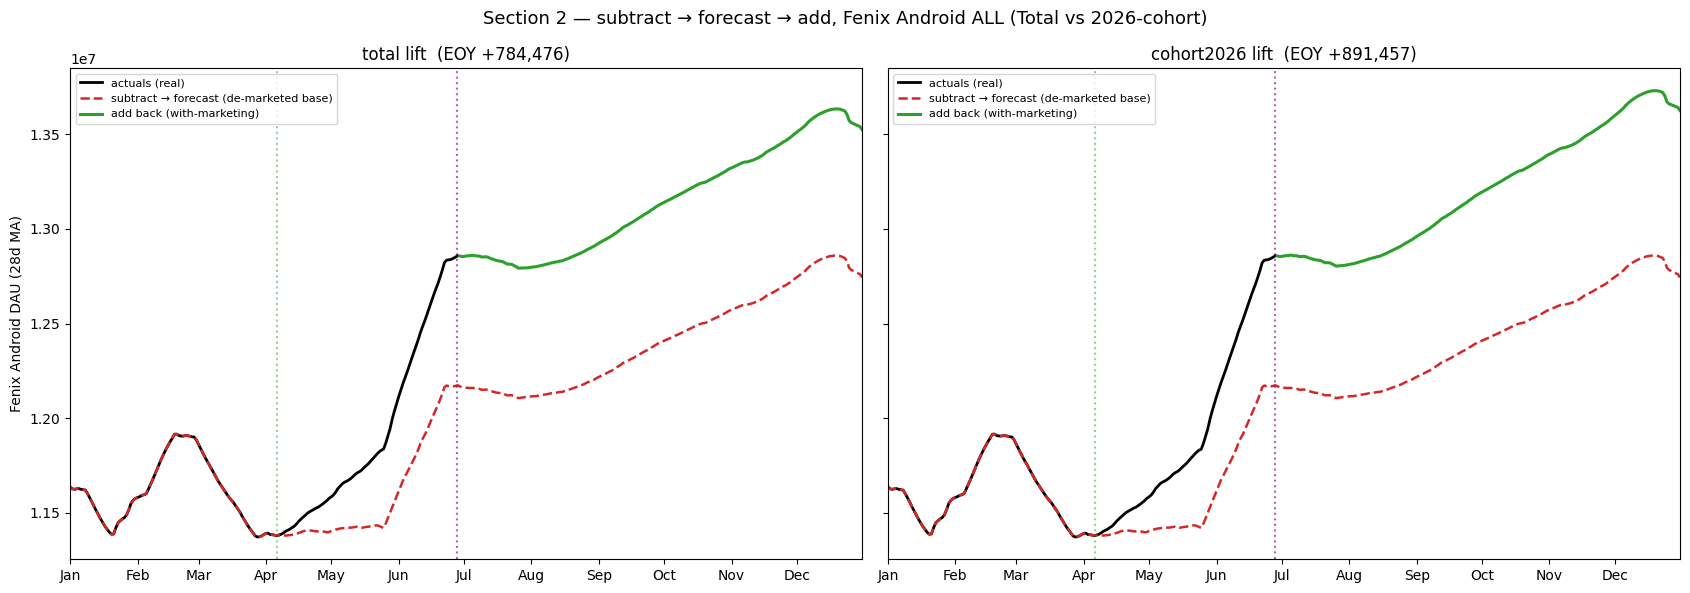

In [8]:
# [s2-procedure]
# Full bidirectional procedure for BOTH lift curves at Fenix Android (country=ALL),
# where the applied lift == the full daily series. Left: Total. Right: 2026-cohort.
#   subtract : actuals − L   (de-marketed training)
#   forecast : mozaic base    (= with-mktg forecast − L)
#   add      : base + L        (= delivered with-marketing forecast)
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
for ax, key in zip(axes, ['total', 'cohort2026']):
    df, L = run_df[key], lift_s[key]
    act = full_daily(df, 'fenix_android')  # training+forecast; training portion == real actuals
    act_hist = act.loc[:SEAM]
    fc = act.loc[FORECAST_START_S2:]
    L_hist = L.reindex(act_hist.index).fillna(0.0)
    L_fc = L.reindex(fc.index).fillna(0.0)
    demk_hist = act_hist - L_hist
    base_fc = fc - L_fc
    # subtract (history) + forecast (base) as one de-marketed daily series -> MA
    demk_daily = pd.concat([demk_hist, base_fc]).sort_index()
    addback_daily = pd.concat([act_hist, fc]).sort_index()   # history=actuals, forward=with-mktg
    ax.plot(daily_to_28ma(act_hist.index, act_hist.values).loc[PLOT_START:SEAM],
            color='black', lw=2.0, label='actuals (real)')
    ax.plot(daily_to_28ma(demk_daily.index, demk_daily.values).loc[PLOT_START:EOY],
            color='tab:red', lw=1.8, ls='--', label='subtract → forecast (de-marketed base)')
    ax.plot(daily_to_28ma(addback_daily.index, addback_daily.values).loc[FORECAST_START_S2:EOY],
            color='tab:green', lw=2.2, label='add back (with-marketing)')
    ax.axvline(SEAM, color='purple', ls=':', alpha=0.6)
    ax.axvline(CAMPAIGN_LAUNCH, color='green', ls=':', alpha=0.4)
    ax.set_title(f'{key} lift  (EOY {L.loc[EOY]:+,.0f})')
    ax.set_xlim(PLOT_START, EOY)
    ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('Fenix Android DAU (28d MA)')
fig.suptitle('Section 2 — subtract → forecast → add, Fenix Android ALL (Total vs 2026-cohort)', fontsize=13)
plt.tight_layout(); plt.show()


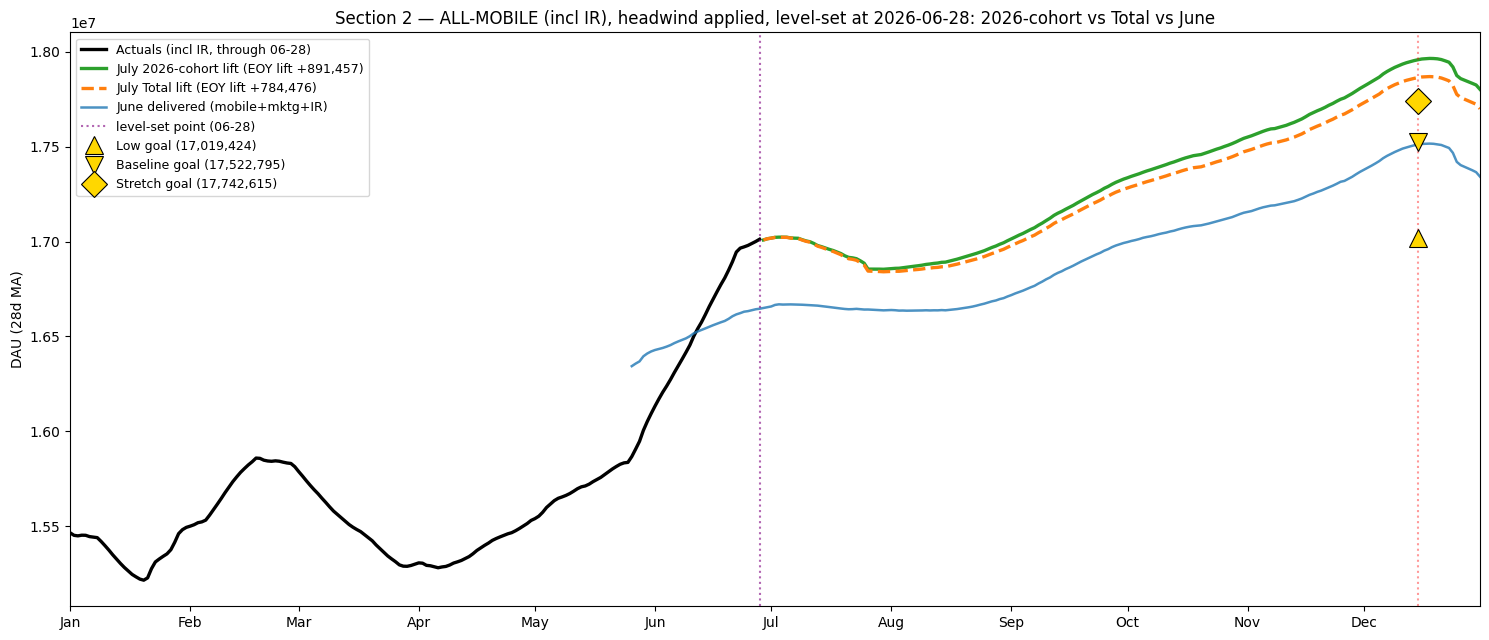

ALL-MOBILE 28d-MA (incl Iran), level-set at 2026-06-28:

 2026-12-15:   June delivered = 17,511,100
   July 2026-cohort:    17,958,129   vs June    +447,029   (marketing Δ vs June  +243,710)
   July Total     :    17,863,912   vs June    +352,812   (marketing Δ vs June  +142,885)
   2026-cohort − Total:     +94,216  (= Pre-2026 forward decline)

 2026-12-31:   June delivered = 17,342,037
   July 2026-cohort:    17,801,964   vs June    +459,927   (marketing Δ vs June  +245,978)
   July Total     :    17,700,081   vs June    +358,044   (marketing Δ vs June  +138,997)
   2026-cohort − Total:    +101,883  (= Pre-2026 forward decline)

=== Dec-15 28d-MA vs July canonical stakeholder goals (mobile) ===
  Low         17,019,424
  Baseline    17,522,795
  Stretch     17,742,615
  ----------------------------------------
  July 2026-cohort:   17,958,129   [Low:   +938,705 | Baseline:   +435,334 | Stretch:   +215,514]
  July Total     :   17,863,912   [Low:   +844,488 | Baseline:   +341,117 | St

In [9]:
# [s2-kpi-compare]
# ALL-MOBILE (country=ALL, incl Iran) KPI, level-set at the most recent actual
# day (2026-06-28) via the canonical display_ma: each curve = 28d-MA of
# [actuals through SEAM ++ that run's forecast], so both are pinned to the true
# actual level at SEAM and diverge only forward. Overlaid with June's delivered curve.
curves = {}
for key in ['total', 'cohort2026']:
    s = full_daily(run_df[key], 'ALL MOBILE', country='ALL')      # training+forecast daily
    # headwind (adj-h, copied from June) applied to the MA curve, like the canonical
    curves[key] = with_headwind(display_ma(s.index, s.values, FORECAST_START_S2))
# actuals (shared history) = training portion 28dMA
act_series = full_daily(run_df['total'], 'ALL MOBILE', country='ALL').loc[:SEAM]
act_ma = daily_to_28ma(act_series.index, act_series.values)
june_kpi = jc['mobile_current_june_plus_iran']

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.plot(act_ma.loc[PLOT_START:SEAM].index, act_ma.loc[PLOT_START:SEAM],
        color='black', lw=2.4, label='Actuals (incl IR, through 06-28)')
ax.plot(curves['cohort2026'].loc[FORECAST_START_S2:EOY].index, curves['cohort2026'].loc[FORECAST_START_S2:EOY],
        color='tab:green', lw=2.4, label=f"July 2026-cohort lift (EOY lift {lift_s['cohort2026'].loc[EOY]:+,.0f})")
ax.plot(curves['total'].loc[FORECAST_START_S2:EOY].index, curves['total'].loc[FORECAST_START_S2:EOY],
        color='tab:orange', lw=2.4, ls='--', label=f"July Total lift (EOY lift {lift_s['total'].loc[EOY]:+,.0f})")
ax.plot(june_kpi.loc[PLOT_START:EOY].index, june_kpi.loc[PLOT_START:EOY],
        color='tab:blue', lw=1.8, alpha=0.8, label='June delivered (mobile+mktg+IR)')
ax.axvline(SEAM, color='purple', ls=':', alpha=0.6, label='level-set point (06-28)')
ax.axvline(pd.Timestamp('2026-12-15'), color='red', ls=':', alpha=0.4)

# Stakeholder Dec-15 goals from the July canonical notebook (mobile KPI).
GOALS = {'Low': 17_019_424, 'Baseline': 17_522_795, 'Stretch': 17_742_615}
for (lab, val), mk in zip(GOALS.items(), ['^', 'v', 'D']):
    ax.plot(pd.Timestamp('2026-12-15'), val, marker=mk, color='gold', markersize=13,
            markeredgecolor='black', markeredgewidth=0.8, linestyle='None',
            label=f'{lab} goal ({val:,})')
ax.set_title('Section 2 — ALL-MOBILE (incl IR), headwind applied, level-set at 2026-06-28: 2026-cohort vs Total vs June')
ax.set_ylabel('DAU (28d MA)'); ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()

print('ALL-MOBILE 28d-MA (incl Iran), level-set at 2026-06-28:')
for d in [pd.Timestamp('2026-12-15'), pd.Timestamp('2026-12-31')]:
    jn = june_kpi.loc[d]
    print(f'\n {d.date()}:   June delivered = {jn:,.0f}')
    for key, lab in [('cohort2026', '2026-cohort'), ('total', 'Total     ')]:
        v = curves[key].loc[d]
        print(f'   July {lab}: {v:>13,.0f}   vs June {v-jn:>+11,.0f}   (marketing Δ vs June {lift_s[key].loc[d]-june_lift.loc[d]:>+9,.0f})')
    print(f'   2026-cohort − Total: {curves["cohort2026"].loc[d]-curves["total"].loc[d]:>+11,.0f}  (= Pre-2026 forward decline)')

# Dec-15 vs stakeholder goals
print('\n=== Dec-15 28d-MA vs July canonical stakeholder goals (mobile) ===')
d15 = pd.Timestamp('2026-12-15')
for gl, gv in GOALS.items():
    print(f'  {gl:<9} {gv:>12,.0f}')
print('  ' + '-' * 40)
for key, lab in [('cohort2026', 'July 2026-cohort'), ('total', 'July Total     '), (None, 'June delivered ')]:
    v = june_kpi.loc[d15] if key is None else curves[key].loc[d15]
    verdicts = ' | '.join(f'{gl}: {v-gv:>+10,.0f}' for gl, gv in GOALS.items())
    print(f'  {lab}: {v:>12,.0f}   [{verdicts}]')


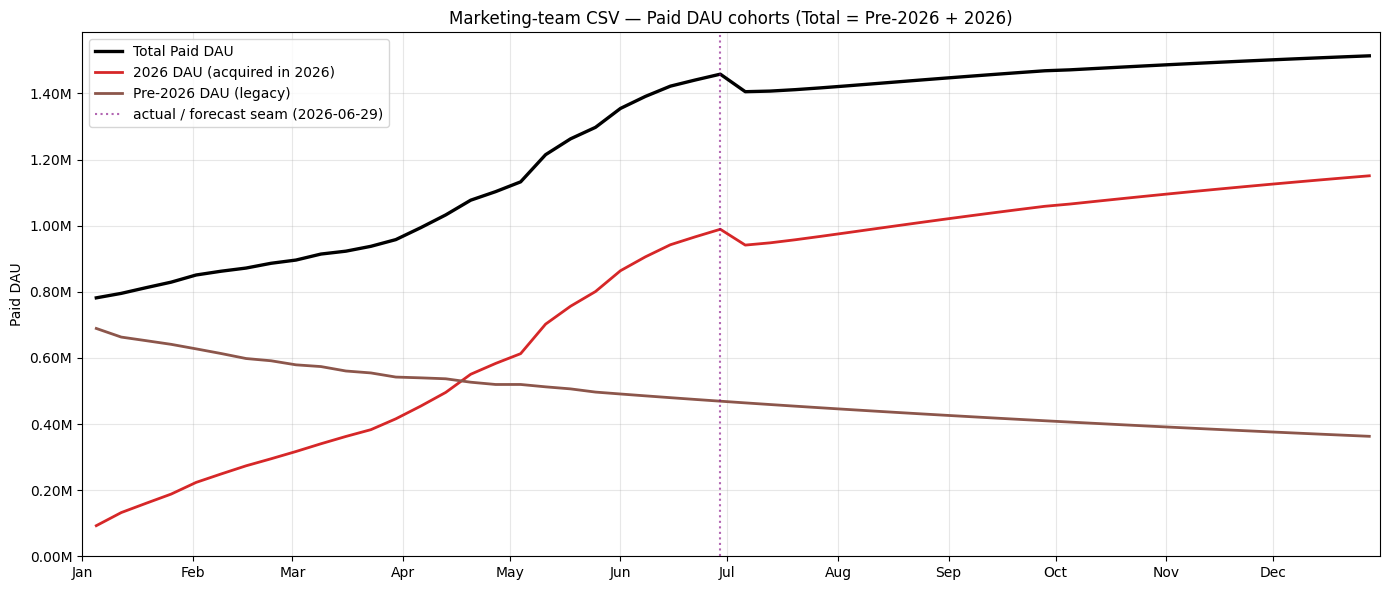

In [10]:
# [marketing-columns-only]
# Just the three marketing-team CSV series: Total Paid DAU = Pre-2026 + 2026.
import matplotlib.ticker as mticker
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(csv.index, csv['Total Paid DAU'], color='black', linewidth=2.4, label='Total Paid DAU')
ax.plot(csv.index, csv['2026 DAU'], color='tab:red', linewidth=2.0, label='2026 DAU (acquired in 2026)')
ax.plot(csv.index, csv['Pre-2026 DAU'], color='tab:brown', linewidth=2.0, label='Pre-2026 DAU (legacy)')
ax.axvline(CSV_ACTUAL_END, color='purple', linestyle=':', alpha=0.6,
           label=f'actual / forecast seam ({CSV_ACTUAL_END.date()})')
ax.set_title('Marketing-team CSV — Paid DAU cohorts (Total = Pre-2026 + 2026)')
ax.set_ylabel('Paid DAU')
ax.set_xlim(PLOT_START, EOY)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


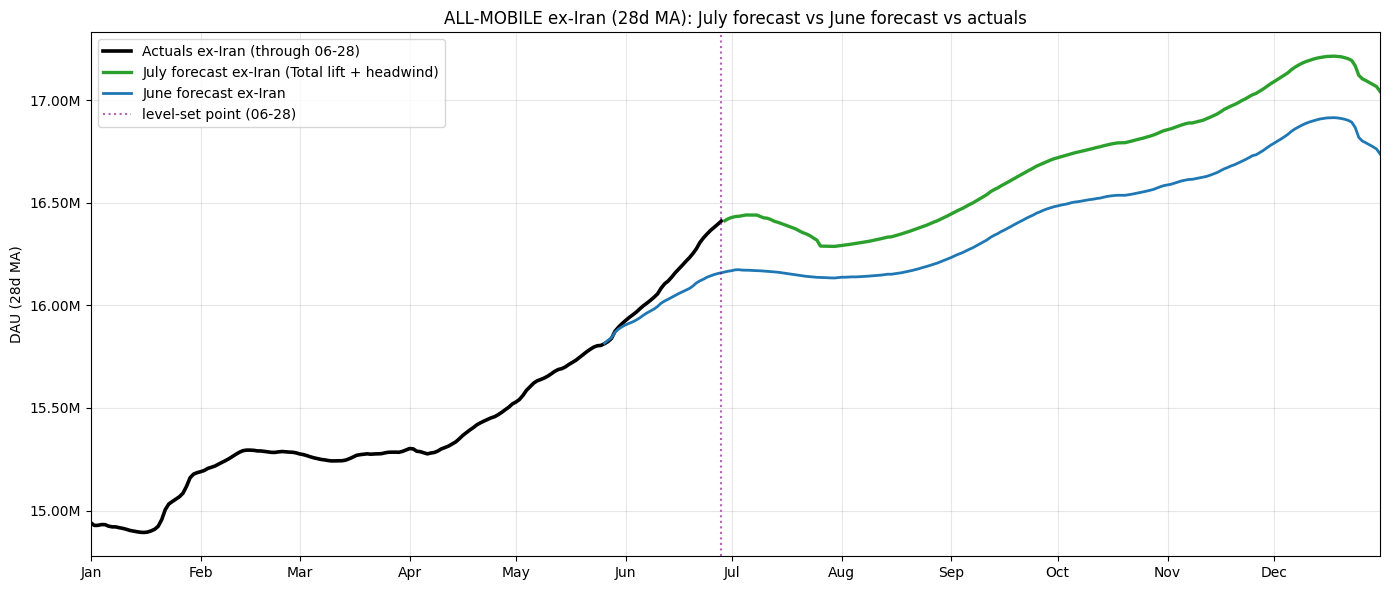

In [11]:
# [ex-iran-june-july-actuals]
# ALL-MOBILE excluding Iran, 28d-MA: current July forecast (Total lift + headwind),
# prior June forecast, and actuals. Removing Iran strips out the reconnection-bounce
# noise so the underlying trajectories are directly comparable.
import matplotlib.ticker as mticker
jul_ex_daily = full_daily(run_df['total'], 'ALL MOBILE', country='ALL', excl_ir=True)   # training+forecast
jul_ex_ma = with_headwind(display_ma(jul_ex_daily.index, jul_ex_daily.values, FORECAST_START_S2))
act_ex = jul_ex_daily.loc[:SEAM]
act_ex_ma = daily_to_28ma(act_ex.index, act_ex.values)
june_ex_ma = jc['mobile_current_june_no_iran']   # forecast-only from June's start (05-26), headwind-adjusted

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(act_ex_ma.loc[PLOT_START:SEAM].index, act_ex_ma.loc[PLOT_START:SEAM],
        color='black', linewidth=2.6, label='Actuals ex-Iran (through 06-28)')
ax.plot(jul_ex_ma.loc[FORECAST_START_S2:EOY].index, jul_ex_ma.loc[FORECAST_START_S2:EOY],
        color='tab:green', linewidth=2.4, label='July forecast ex-Iran (Total lift + headwind)')
ax.plot(june_ex_ma.loc[PLOT_START:EOY].index, june_ex_ma.loc[PLOT_START:EOY],
        color='tab:blue', linewidth=2.0, label='June forecast ex-Iran')
ax.axvline(SEAM, color='purple', linestyle=':', alpha=0.6, label='level-set point (06-28)')
ax.set_title('ALL-MOBILE ex-Iran (28d MA): July forecast vs June forecast vs actuals')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlim(PLOT_START, EOY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


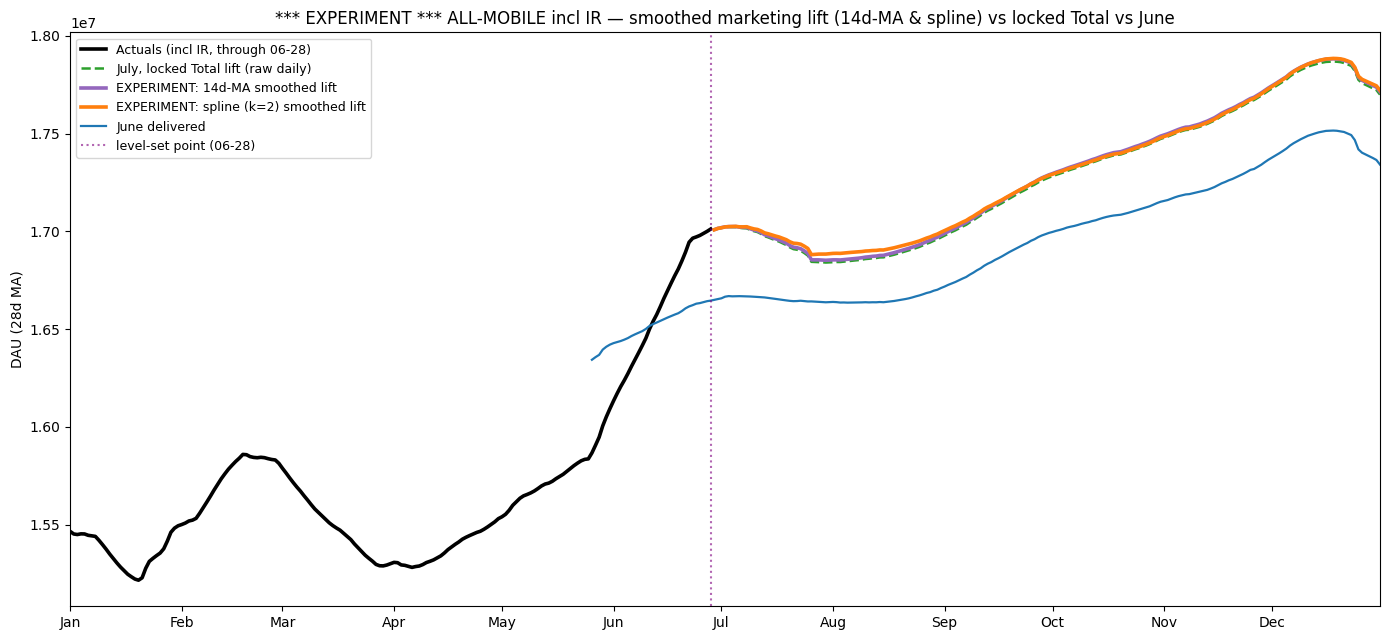

July-Aug dip (kink depth), ALL-MOBILE incl IR:
  locked Total (raw daily)  : seam 17,008,382  Jul-Aug trough 16,840,748  dip -167,633  (at 2026-07-30)
  14d-MA smoothed           : seam 17,008,928  Jul-Aug trough 16,852,466  dip -156,462  (at 2026-07-30)
  spline smoothed           : seam 17,008,668  Jul-Aug trough 16,881,169  dip -127,500  (at 2026-07-26)

Dec-15 (incl IR):
  locked Total  : 17,863,912
  14d-MA        : 17,877,884
  spline        : 17,878,664


In [12]:
# [EXPERIMENT-smoothed-lift]
# ============================================================================
# *** EXPERIMENT ONLY — NOT the locked forecast ***
# Does the marketing lift's DAILY SHAPE drive the July kink? The locked TOTAL lift
# was smoothed two ways and each re-run through the full subtract -> forecast -> add
# pipeline:
#     (1) 14-day centered moving average  (marketing_lift_model.total_14dMA.EXPERIMENT)
#     (2) second-order (k=2) smoothing spline (marketing_lift_model.total_spline2.EXPERIMENT)
# Compared to the locked Total forecast (raw daily lift) and June. ALL-MOBILE incl Iran
# (where the kink is most visible), level-set at 2026-06-28, headwind applied.
# The locked production spec remains marketing_lift_model.total.2026-06-29.
# ============================================================================
EXP_MA_DIR = REPO / 'tmp/mktg_total_14dma_EXPERIMENT_2026-06-29'
EXP_SP_DIR = REPO / 'tmp/mktg_total_spline2_EXPERIMENT_2026-06-29'
exp_ma_df = _load(sorted(glob.glob(str(EXP_MA_DIR / 'mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])
exp_sp_df = _load(sorted(glob.glob(str(EXP_SP_DIR / 'mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])

def _kpi_curve(df):
    s = full_daily(df, 'ALL MOBILE', country='ALL')
    return with_headwind(display_ma(s.index, s.values, FORECAST_START_S2))

curve_raw = _kpi_curve(run_df['total'])     # locked Total (raw daily lift)
curve_ma = _kpi_curve(exp_ma_df)            # 14d-MA smoothed lift
curve_sp = _kpi_curve(exp_sp_df)            # spline smoothed lift
act = full_daily(run_df['total'], 'ALL MOBILE', country='ALL').loc[:SEAM]
act_ma = daily_to_28ma(act.index, act.values)
june_kpi = jc['mobile_current_june_plus_iran']

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(act_ma.loc[PLOT_START:SEAM].index, act_ma.loc[PLOT_START:SEAM],
        color='black', linewidth=2.6, label='Actuals (incl IR, through 06-28)')
ax.plot(curve_raw.loc[FORECAST_START_S2:EOY].index, curve_raw.loc[FORECAST_START_S2:EOY],
        color='tab:green', linewidth=1.8, linestyle='--', label='July, locked Total lift (raw daily)')
ax.plot(curve_ma.loc[FORECAST_START_S2:EOY].index, curve_ma.loc[FORECAST_START_S2:EOY],
        color='tab:purple', linewidth=2.6, label='EXPERIMENT: 14d-MA smoothed lift')
ax.plot(curve_sp.loc[FORECAST_START_S2:EOY].index, curve_sp.loc[FORECAST_START_S2:EOY],
        color='tab:orange', linewidth=2.6, label='EXPERIMENT: spline (k=2) smoothed lift')
ax.plot(june_kpi.loc[PLOT_START:EOY].index, june_kpi.loc[PLOT_START:EOY],
        color='tab:blue', linewidth=1.6, label='June delivered')
ax.axvline(SEAM, color='purple', linestyle=':', alpha=0.6, label='level-set point (06-28)')
ax.set_title('*** EXPERIMENT *** ALL-MOBILE incl IR — smoothed marketing lift (14d-MA & spline) vs locked Total vs June')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()

def trough(curve):
    seg = curve.loc[FORECAST_START_S2:'2026-08-31']
    return curve.loc[FORECAST_START_S2], seg.min(), seg.idxmin()
print('July-Aug dip (kink depth), ALL-MOBILE incl IR:')
for lab, cv in [('locked Total (raw daily)', curve_raw), ('14d-MA smoothed', curve_ma), ('spline smoothed', curve_sp)]:
    st, tr, trd = trough(cv)
    print(f"  {lab:26}: seam {st:,.0f}  Jul-Aug trough {tr:,.0f}  dip {tr-st:+,.0f}  (at {trd.date()})")
print('\nDec-15 (incl IR):')
for lab, cv in [('locked Total', curve_raw), ('14d-MA', curve_ma), ('spline', curve_sp)]:
    print(f"  {lab:14}: {cv.loc['2026-12-15']:,.0f}")


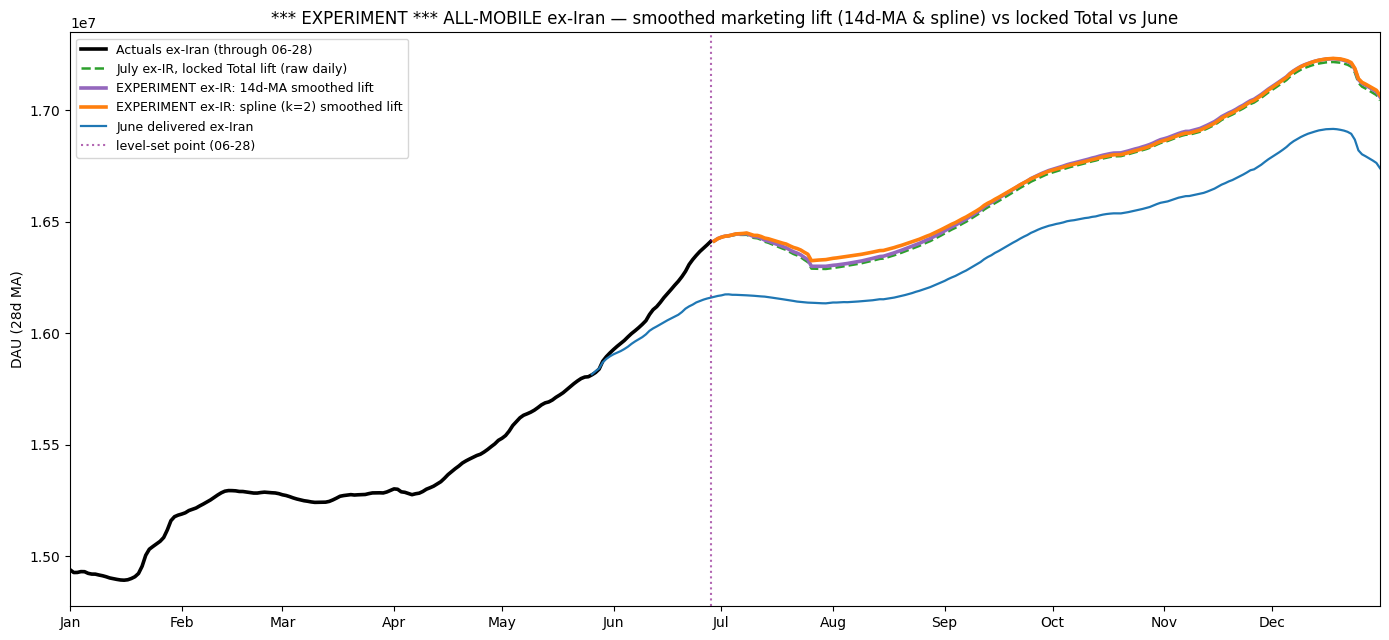

July-Aug dip (kink depth), ALL-MOBILE EX-IRAN:
  locked Total (raw daily)  : seam 16,413,179  Jul-Aug trough 16,287,936  dip -125,243  (at 2026-07-30)
  14d-MA smoothed           : seam 16,413,751  Jul-Aug trough 16,299,896  dip -113,854  (at 2026-07-30)
  spline smoothed           : seam 16,413,491  Jul-Aug trough 16,325,010  dip -88,481  (at 2026-07-26)


In [13]:
# [EXPERIMENT-smoothed-lift-exiran]
# *** EXPERIMENT ONLY — NOT the locked forecast *** ex-Iran version of the smoothed-lift
# comparison (ALL-MOBILE minus Iran), so the Iran reconnection-bounce noise is stripped
# and we see the marketing lift's effect on the clean base. Level-set at 06-28, headwind applied.
exp_ma_df = _load(sorted(glob.glob(str(REPO / 'tmp/mktg_total_14dma_EXPERIMENT_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])
exp_sp_df = _load(sorted(glob.glob(str(REPO / 'tmp/mktg_total_spline2_EXPERIMENT_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])

def _kpi_curve_exir(df):
    s = full_daily(df, 'ALL MOBILE', country='ALL', excl_ir=True)
    return with_headwind(display_ma(s.index, s.values, FORECAST_START_S2))

exir_raw = _kpi_curve_exir(run_df['total'])
exir_ma = _kpi_curve_exir(exp_ma_df)
exir_sp = _kpi_curve_exir(exp_sp_df)
act_ex = full_daily(run_df['total'], 'ALL MOBILE', country='ALL', excl_ir=True).loc[:SEAM]
act_ex_ma = daily_to_28ma(act_ex.index, act_ex.values)
june_ex = jc['mobile_current_june_no_iran']

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(act_ex_ma.loc[PLOT_START:SEAM].index, act_ex_ma.loc[PLOT_START:SEAM],
        color='black', linewidth=2.6, label='Actuals ex-Iran (through 06-28)')
ax.plot(exir_raw.loc[FORECAST_START_S2:EOY].index, exir_raw.loc[FORECAST_START_S2:EOY],
        color='tab:green', linewidth=1.8, linestyle='--', label='July ex-IR, locked Total lift (raw daily)')
ax.plot(exir_ma.loc[FORECAST_START_S2:EOY].index, exir_ma.loc[FORECAST_START_S2:EOY],
        color='tab:purple', linewidth=2.6, label='EXPERIMENT ex-IR: 14d-MA smoothed lift')
ax.plot(exir_sp.loc[FORECAST_START_S2:EOY].index, exir_sp.loc[FORECAST_START_S2:EOY],
        color='tab:orange', linewidth=2.6, label='EXPERIMENT ex-IR: spline (k=2) smoothed lift')
ax.plot(june_ex.loc[PLOT_START:EOY].index, june_ex.loc[PLOT_START:EOY],
        color='tab:blue', linewidth=1.6, label='June delivered ex-Iran')
ax.axvline(SEAM, color='purple', linestyle=':', alpha=0.6, label='level-set point (06-28)')
ax.set_title('*** EXPERIMENT *** ALL-MOBILE ex-Iran — smoothed marketing lift (14d-MA & spline) vs locked Total vs June')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()

def trough(curve):
    seg = curve.loc[FORECAST_START_S2:'2026-08-31']
    return curve.loc[FORECAST_START_S2], seg.min(), seg.idxmin()
print('July-Aug dip (kink depth), ALL-MOBILE EX-IRAN:')
for lab, cv in [('locked Total (raw daily)', exir_raw), ('14d-MA smoothed', exir_ma), ('spline smoothed', exir_sp)]:
    st, tr, trd = trough(cv)
    print(f"  {lab:26}: seam {st:,.0f}  Jul-Aug trough {tr:,.0f}  dip {tr-st:+,.0f}  (at {trd.date()})")


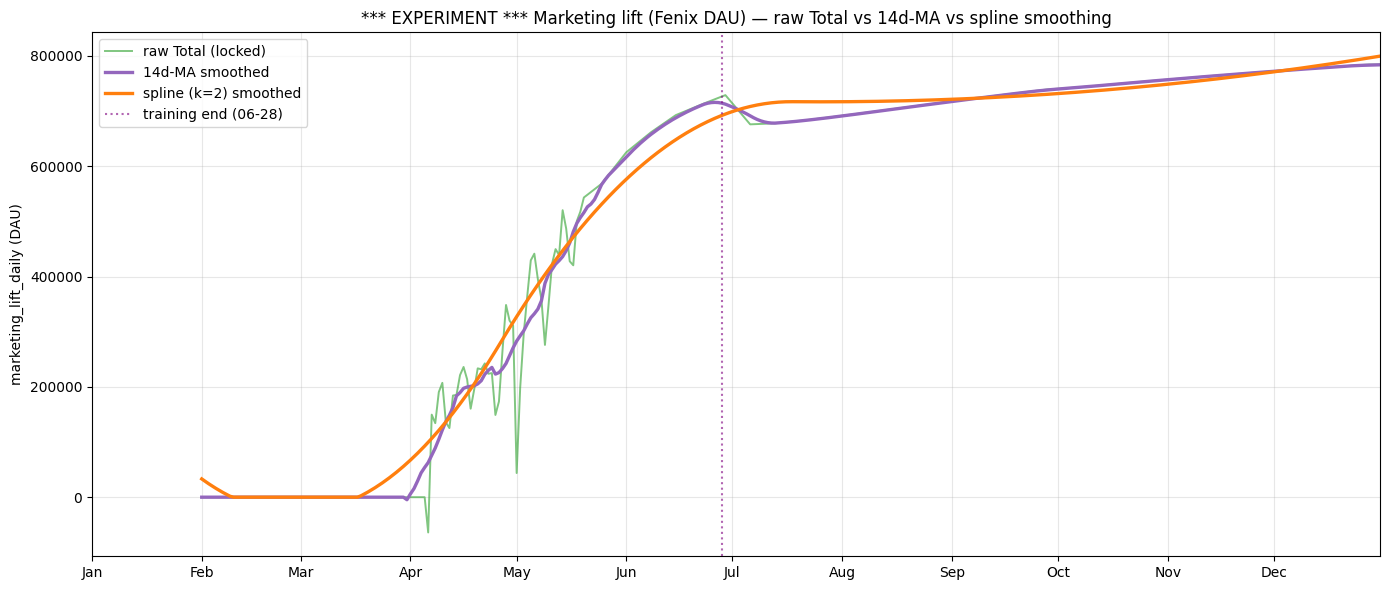

In [14]:
# [EXPERIMENT-lift-curves]
# *** EXPERIMENT ONLY *** The smoothed marketing DAU each experiment represents:
# the raw Total lift vs its 14d-MA and spline (k=2) smoothings — i.e. the actual
# marketing_lift_daily series fed into each re-run.
_liftp = {
    'raw Total (locked)': 'marketing_lift_model.total.2026-06-29.parquet',
    '14d-MA smoothed': 'marketing_lift_model.total_14dMA.EXPERIMENT.2026-06-29.parquet',
    'spline (k=2) smoothed': 'marketing_lift_model.total_spline2.EXPERIMENT.2026-06-29.parquet',
}
_mdir = REPO / 'data-official/2026-07/marketing'
_styles = {'raw Total (locked)': dict(color='tab:green', lw=1.4, alpha=0.6),
           '14d-MA smoothed': dict(color='tab:purple', lw=2.4),
           'spline (k=2) smoothed': dict(color='tab:orange', lw=2.4)}
fig, ax = plt.subplots(figsize=(14, 6))
for lab, fn in _liftp.items():
    s = pd.read_parquet(_mdir / fn)['marketing_lift_daily']
    s.index = pd.DatetimeIndex(s.index).normalize()
    ax.plot(s.loc[PLOT_START:EOY].index, s.loc[PLOT_START:EOY], label=lab, **_styles[lab])
ax.axvline(SEAM, color='purple', linestyle=':', alpha=0.6, label='training end (06-28)')
ax.set_title('*** EXPERIMENT *** Marketing lift (Fenix DAU) — raw Total vs 14d-MA vs spline smoothing')
ax.set_ylabel('marketing_lift_daily (DAU)')
ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


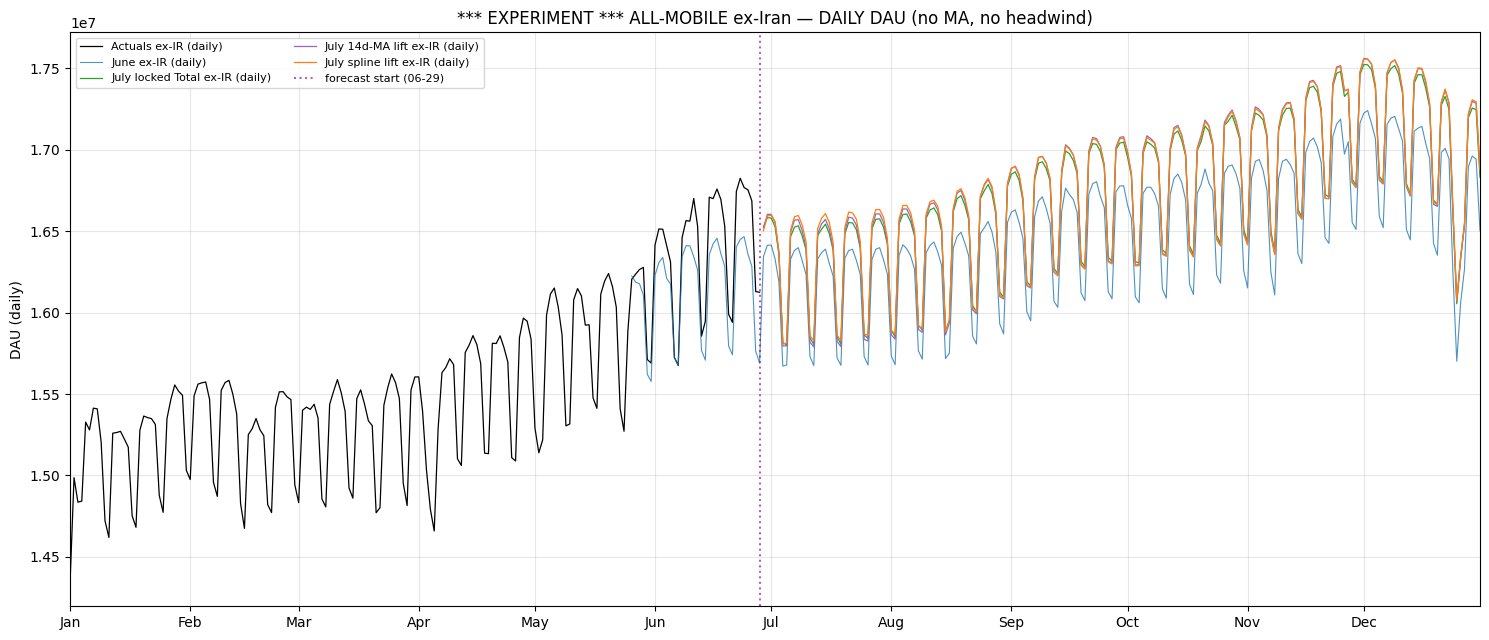

ex-Iran DAILY DAU (no MA, no headwind) — July variants at sample dates:
          date   locked Total         14d-MA         spline
    2026-07-06     16,466,367     16,491,371     16,504,863
    2026-07-13     16,472,789     16,483,841     16,515,270
    2026-07-20     16,481,803     16,493,170     16,521,359
    2026-07-27     16,512,777     16,524,352     16,548,369
    2026-08-10     16,577,916     16,590,853     16,604,180
    2026-09-01     16,848,000     16,884,013     16,885,725


In [15]:
# [EXPERIMENT-exiran-daily]
# *** EXPERIMENT ONLY *** ex-Iran DAILY DAU (no moving average, no headwind) for the
# same curves: actuals + the three July variants (locked Total / 14d-MA / spline) + June.
# Daily shows the raw weekday/weekend swing and whether the dip is real in the daily
# forecast or just a 28d-MA rolling effect. ALL-MOBILE minus Iran.
exp_ma_df = _load(sorted(glob.glob(str(REPO / 'tmp/mktg_total_14dma_EXPERIMENT_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])
exp_sp_df = _load(sorted(glob.glob(str(REPO / 'tmp/mktg_total_spline2_EXPERIMENT_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])
# June ex-Iran = June's no-Iran parquet (adj-m, IR absent -> country ALL is already ex-Iran).
_jun = _load(str(REPO / 'data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.gm-D.adj-m.parquet'))
def _jun_daily():
    x = _jun[(_jun.data_source == 'glean_mobile') & (_jun.country == 'ALL') & (_jun.app_name == 'ALL MOBILE')
             & (_jun.segment == '{}') & (_jun.data_type == 'forecast')]
    return x.set_index('target_date').sort_index()['dau']

def _daily_exir(df):   # full ex-Iran daily (training+forecast), NO headwind
    return full_daily(df, 'ALL MOBILE', country='ALL', excl_ir=True)

d_raw = _daily_exir(run_df['total']); d_ma = _daily_exir(exp_ma_df); d_sp = _daily_exir(exp_sp_df)
d_act = d_raw.loc[:SEAM]
d_june = _jun_daily()

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.plot(d_act.loc[PLOT_START:SEAM].index, d_act.loc[PLOT_START:SEAM], color='black', lw=0.9, label='Actuals ex-IR (daily)')
ax.plot(d_june.loc[:EOY].index, d_june.loc[:EOY], color='tab:blue', lw=0.8, alpha=0.8, label='June ex-IR (daily)')
ax.plot(d_raw.loc[FORECAST_START_S2:EOY].index, d_raw.loc[FORECAST_START_S2:EOY], color='tab:green', lw=0.9, label='July locked Total ex-IR (daily)')
ax.plot(d_ma.loc[FORECAST_START_S2:EOY].index, d_ma.loc[FORECAST_START_S2:EOY], color='tab:purple', lw=0.9, label='July 14d-MA lift ex-IR (daily)')
ax.plot(d_sp.loc[FORECAST_START_S2:EOY].index, d_sp.loc[FORECAST_START_S2:EOY], color='tab:orange', lw=0.9, label='July spline lift ex-IR (daily)')
ax.axvline(SEAM, color='purple', linestyle=':', alpha=0.6, label='forecast start (06-29)')
ax.set_title('*** EXPERIMENT *** ALL-MOBILE ex-Iran — DAILY DAU (no MA, no headwind)')
ax.set_ylabel('DAU (daily)')
ax.set_xlim(PLOT_START, EOY)
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('ex-Iran DAILY DAU (no MA, no headwind) — July variants at sample dates:')
print(f"  {'date':>12} {'locked Total':>14} {'14d-MA':>14} {'spline':>14}")
for d in ['2026-07-06', '2026-07-13', '2026-07-20', '2026-07-27', '2026-08-10', '2026-09-01']:
    t = pd.Timestamp(d)
    print(f"  {d:>12} {d_raw.loc[t]:>14,.0f} {d_ma.loc[t]:>14,.0f} {d_sp.loc[t]:>14,.0f}")


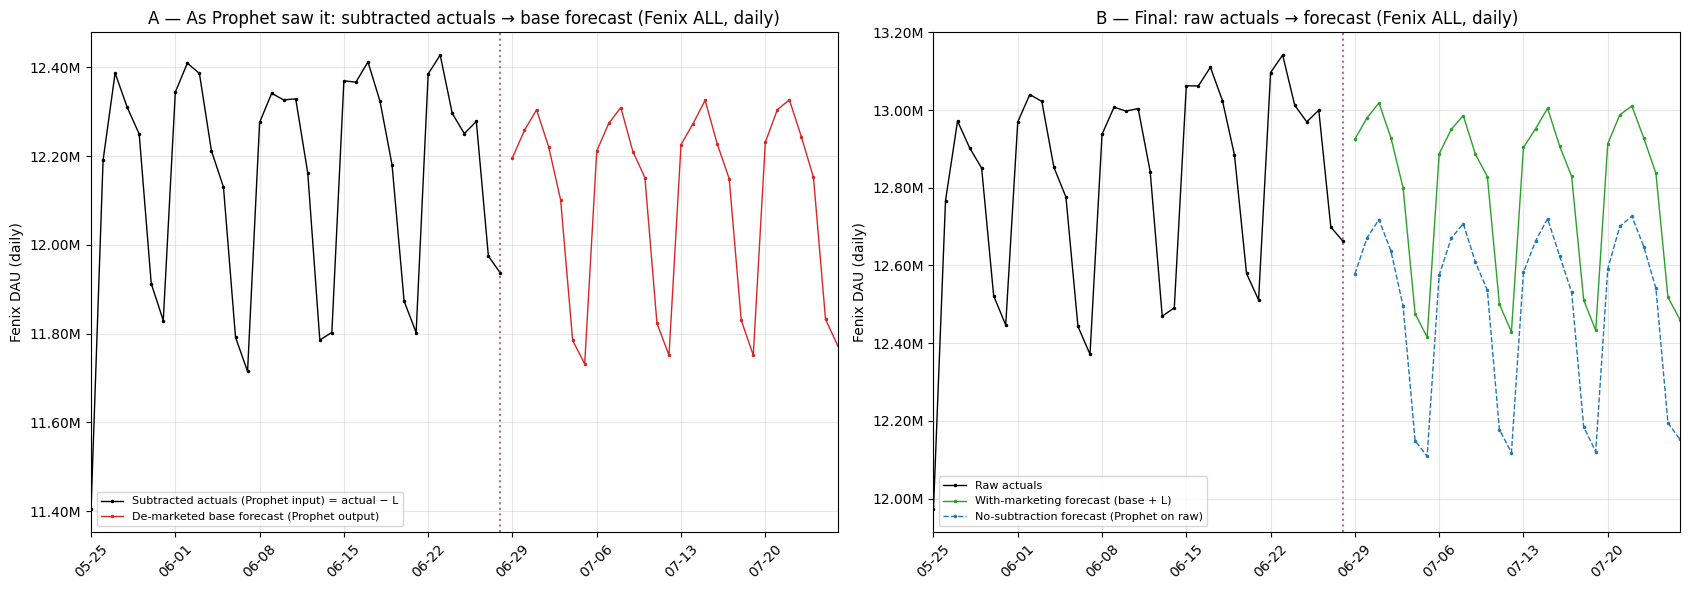

Seam steps (Sun 06-28 -> Mon 06-29), Fenix ALL:
  de-marketed (Prophet's own): 11,936,203 -> 12,196,422  = +260,219
  final (raw -> base+L):       12,662,693 -> 12,925,417  = +262,724
  no-subtraction (raw -> base):12,662,693 -> 12,578,051  = -84,642


In [16]:
# [seam-diagnostic]
# Does Prophet's forecast connect to the SUBTRACTED training it was fed? Raw daily
# (no MA, no headwind), Fenix Android country=ALL (the marketing-subtraction target).
#   Panel A: what Prophet saw+produced = (with-mktg output - L): subtracted actuals -> base forecast.
#   Panel B: final delivered = raw actuals -> with-mktg forecast (base+L); plus the no-subtraction
#            run (Prophet on raw) as a control.
# Finding: the subtracted->forecast handoff is smooth; the visible ALL-MOBILE step comes from the
# NON-Fenix apps reverting a late-June above-trend surge, not from the subtraction.
import matplotlib.ticker as mticker

_nom = _load(sorted(glob.glob(str(REPO / 'tmp/no_mktg_2026-06-29/mozaic_daily_forecast.2026-06-29.gm-D*.parquet')))[0])
_tot = run_df['total']
_L = lift_s['total']

def _fen(df, dt):
    x = df[(df.data_source == 'glean_mobile') & (df.country == 'ALL') & (df.app_name == 'fenix_android')
           & (df.segment == '{}') & (df.data_type == dt)]
    return x.set_index('target_date').sort_index()['dau']

_SEAM = pd.Timestamp('2026-06-28'); _FS = pd.Timestamp('2026-06-29')
_lo, _hi = pd.Timestamp('2026-05-25'), pd.Timestamp('2026-07-26')

tot_tr, tot_fc = _fen(_tot, 'training'), _fen(_tot, 'forecast')
demk_tr = tot_tr - _L.reindex(tot_tr.index).fillna(0.0)      # subtracted actuals (Prophet input)
demk_fc = tot_fc - _L.reindex(tot_fc.index).fillna(0.0)      # de-marketed base forecast (Prophet output)
raw_tr = _fen(_nom, 'training')                              # untouched raw actuals
final_fc = tot_fc                                            # base + L
nomk_fc = _fen(_nom, 'forecast')                             # Prophet on raw (no subtraction) — control

fig, (axA, axB) = plt.subplots(1, 2, figsize=(17, 6))
axA.plot(demk_tr.loc[_lo:_SEAM].index, demk_tr.loc[_lo:_SEAM], color='black', marker='.', ms=3, lw=1.0,
         label='Subtracted actuals (Prophet input) = actual − L')
axA.plot(demk_fc.loc[_FS:_hi].index, demk_fc.loc[_FS:_hi], color='tab:red', marker='.', ms=3, lw=1.0,
         label='De-marketed base forecast (Prophet output)')
axA.axvline(_SEAM, color='purple', ls=':', alpha=0.6)
axA.set_title('A — As Prophet saw it: subtracted actuals → base forecast (Fenix ALL, daily)')

axB.plot(raw_tr.loc[_lo:_SEAM].index, raw_tr.loc[_lo:_SEAM], color='black', marker='.', ms=3, lw=1.0,
         label='Raw actuals')
axB.plot(final_fc.loc[_FS:_hi].index, final_fc.loc[_FS:_hi], color='tab:green', marker='.', ms=3, lw=1.0,
         label='With-marketing forecast (base + L)')
axB.plot(nomk_fc.loc[_FS:_hi].index, nomk_fc.loc[_FS:_hi], color='tab:blue', marker='.', ms=3, lw=1.0, ls='--',
         label='No-subtraction forecast (Prophet on raw)')
axB.axvline(_SEAM, color='purple', ls=':', alpha=0.6)
axB.set_title('B — Final: raw actuals → forecast (Fenix ALL, daily)')

for ax in (axA, axB):
    ax.set_xlim(_lo, _hi); ax.set_ylabel('Fenix DAU (daily)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
    ax.legend(fontsize=8, loc='lower left'); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

print('Seam steps (Sun 06-28 -> Mon 06-29), Fenix ALL:')
print(f"  de-marketed (Prophet's own): {demk_tr[_SEAM]:,.0f} -> {demk_fc[_FS]:,.0f}  = {demk_fc[_FS]-demk_tr[_SEAM]:+,.0f}")
print(f"  final (raw -> base+L):       {raw_tr[_SEAM]:,.0f} -> {final_fc[_FS]:,.0f}  = {final_fc[_FS]-raw_tr[_SEAM]:+,.0f}")
print(f"  no-subtraction (raw -> base):{raw_tr[_SEAM]:,.0f} -> {nomk_fc[_FS]:,.0f}  = {nomk_fc[_FS]-raw_tr[_SEAM]:+,.0f}")


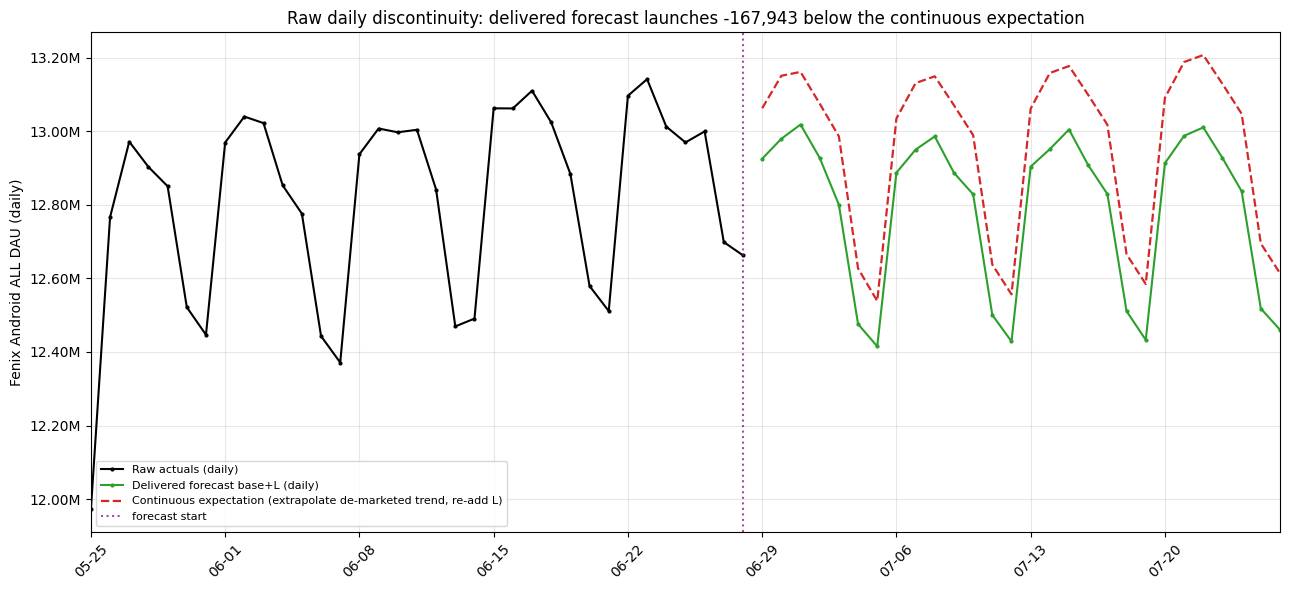

first-forecast-week mean vs continuous expectation: -167,943


In [17]:
# [raw-seam-discontinuity]
# RAW DAILY (no MA): the delivered forecast steps ~150k BELOW a continuous
# continuation at the forecast start. This is the true source of the 28d-MA "kink" —
# the step is masked while the high pre-seam actuals sit in the trailing window, then
# surfaces as a slope break once they roll out. Fenix Android ALL, Total lift.
#
# The reference "continuous expectation" is built on the DE-MARKETED series (extrapolate
# its gentle underlying trend) and then re-adds the KNOWN marketing curve L. This is the
# fair comparison: L peaks at the seam and declines after by design, so extrapolating the
# raw ramp (which still includes L rising) would double-count marketing and overstate the
# gap. Since L is added to both the forecast and the reference, it cancels — the residual
# gap is the pure Prophet trend-lag artifact. Reuses run_df / lift_s / full_daily [s2-setup].
import matplotlib.ticker as mticker

df_t, L_t = run_df['total'], lift_s['total']
all_t = full_daily(df_t, 'fenix_android')
act_t = all_t.loc[:SEAM]                       # raw actuals (training)
fc_t = all_t.loc[FORECAST_START_S2:]           # delivered forecast (base + L)
demk_hist = act_t - L_t.reindex(act_t.index).fillna(0.0)   # de-marketed actuals

# Deseasonalize de-marketed actuals by day-of-week (last 12 wk), extrapolate recent trend.
tail = demk_hist.loc[SEAM - pd.Timedelta(weeks=12):SEAM]
dow = (tail / tail.rolling(7, center=True, min_periods=4).mean()).dropna()
dow = dow.groupby(dow.index.dayofweek).mean(); dow = dow / dow.mean()
ds_demk = demk_hist / dow.reindex(demk_hist.index.dayofweek).to_numpy()
recent = ds_demk.loc[SEAM - pd.Timedelta(days=27):SEAM]
xx = (recent.index - SEAM).days.to_numpy()
slope, intercept = np.polyfit(xx, recent.values, 1)
futx = pd.date_range(FORECAST_START_S2, FORECAST_START_S2 + pd.Timedelta(days=27))
cont_demk = pd.Series(intercept + slope * ((futx - SEAM).days.to_numpy()), index=futx) \
            * dow.reindex(futx.dayofweek).to_numpy()
cont_delivered = cont_demk + L_t.reindex(futx).fillna(0.0)   # re-add known marketing curve

lo, hi = pd.Timestamp('2026-05-25'), pd.Timestamp('2026-07-26')
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(act_t.loc[lo:SEAM].index, act_t.loc[lo:SEAM], color='black', marker='.', ms=4,
        label='Raw actuals (daily)')
ax.plot(fc_t.loc[FORECAST_START_S2:hi].index, fc_t.loc[FORECAST_START_S2:hi], color='tab:green',
        marker='.', ms=4, label='Delivered forecast base+L (daily)')
ax.plot(cont_delivered.loc[:hi].index, cont_delivered.loc[:hi], color='tab:red', ls='--', lw=1.6,
        label='Continuous expectation (extrapolate de-marketed trend, re-add L)')
ax.axvline(SEAM, color='purple', ls=':', alpha=.7, label='forecast start')
gap = (fc_t.reindex(futx) - cont_delivered.reindex(futx)).mean()
ax.set_title(f'Raw daily discontinuity: delivered forecast launches {gap:,.0f} below the continuous expectation')
ax.set_xlim(lo, hi); ax.set_ylabel('Fenix Android ALL DAU (daily)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=.3)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()
print(f'first-forecast-week mean vs continuous expectation: {gap:+,.0f}')


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


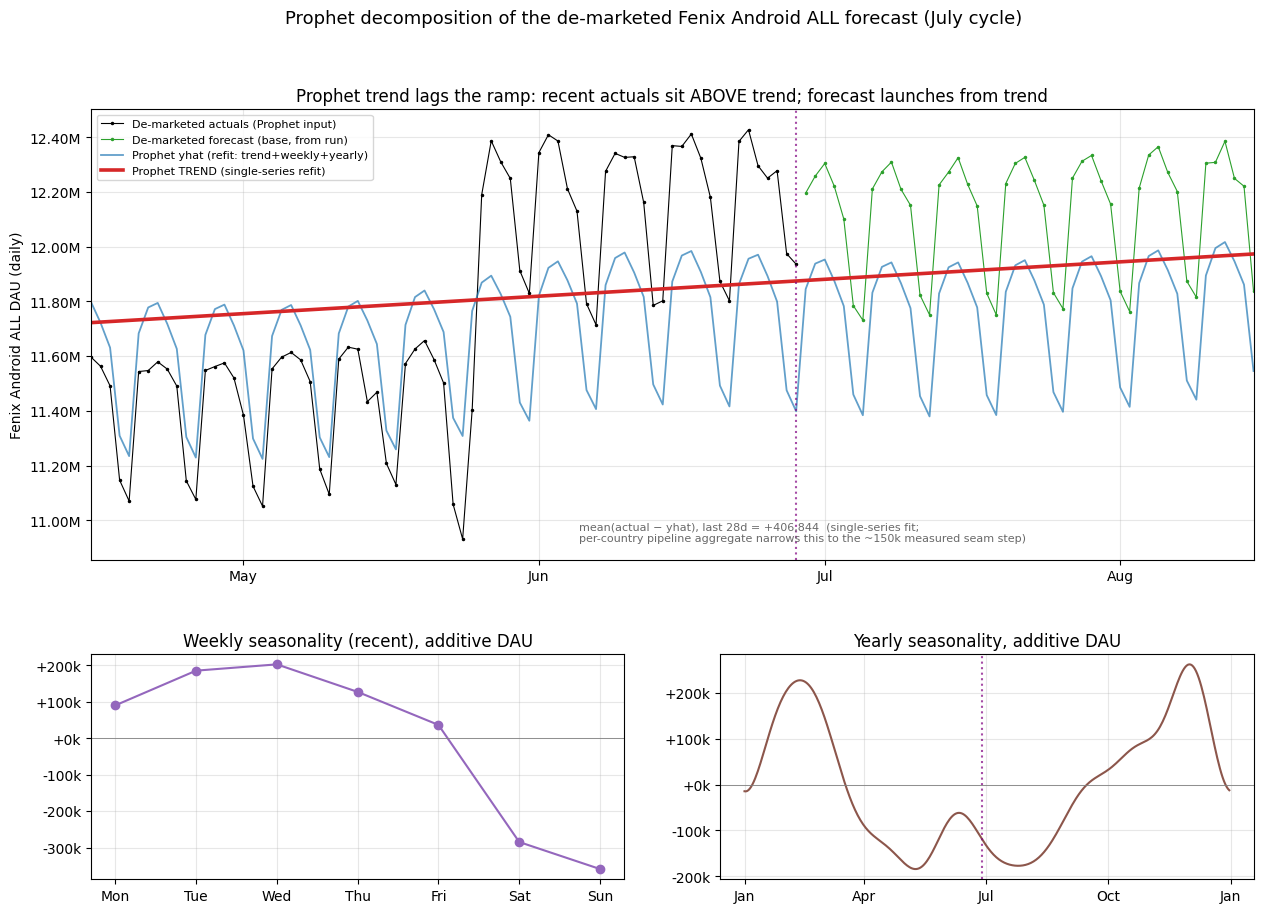

mean residual (actual − yhat) last 28d: +406,844   trend@seam: 11,874,930


In [18]:
# [prophet-decomposition]
# Prophet's trend + weekly + yearly for the de-marketed Fenix ALL series, via
# mozaic's own mobile_forecast_model (cps=0.02, cpr=0.82, linear growth).
# WHY the raw forecast steps down: the heavily-regularized trend (red) barely bends,
# so the June ramp leaves recent actuals ~400k ABOVE it and the forecast launches
# from the trend, not the data. NOTE: this single-series ALL fit OVERSTATES the gap;
# the per-country pipeline aggregate narrows the real seam step to the ~150k measured
# in [raw-seam-discontinuity]. Reuses run_df / lift_s / full_daily from [s2-setup].
import sys as _sys, warnings as _warnings, logging as _logging
_sys.path.insert(0, str(REPO / 'src'))
from mozaic.models import mobile_forecast_model
import matplotlib.ticker as mticker
# Prophet's component matmul emits benign divide/overflow warnings on this fit; silence them.
_warnings.filterwarnings('ignore')
for _n in ('prophet', 'cmdstanpy'):
    _logging.getLogger(_n).setLevel(_logging.CRITICAL)
np.seterr(all='ignore')

df_t, L_t = run_df['total'], lift_s['total']
all_t = full_daily(df_t, 'fenix_android')
demk_hist = all_t.loc[:SEAM] - L_t.reindex(all_t.loc[:SEAM].index).fillna(0.0)
base_fc   = all_t.loc[FORECAST_START_S2:] - L_t.reindex(all_t.loc[FORECAST_START_S2:].index).fillna(0.0)

hist_dates, fc_dates = demk_hist.index, base_fc.index
_, _model, _ = mobile_forecast_model(
    historical_data=pd.Series(demk_hist.values, index=range(len(demk_hist))).astype(float),
    historical_dates=hist_dates, forecast_dates=fc_dates,
    recent_weeks=13, changepoint_prior_scale=0.02, changepoint_range=0.82, n_changepoints=25)
# mozaic predicts forecast-only; re-predict full range to expose the in-sample trend.
_rc = FORECAST_START_S2 - pd.Timedelta(weeks=13)
_full = pd.DatetimeIndex(list(hist_dates) + list(fc_dates)).drop_duplicates().sort_values()
_dfp = pd.DataFrame({'ds': _full}); _dfp['is_historical'] = _dfp.ds < _rc; _dfp['is_recent'] = _dfp.ds >= _rc
comp = _model.predict(_dfp).set_index('ds')
trend, yhat, yearly = comp['trend'], comp['yhat'], comp['yearly']
weekly = comp['weekly_recent']
if 'weekly_historical' in comp.columns:
    weekly = weekly.fillna(0.0) + comp['weekly_historical'].fillna(0.0)

zlo, zhi = pd.Timestamp('2026-04-15'), pd.Timestamp('2026-08-15')
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.0], hspace=0.28, wspace=0.18)

ax = fig.add_subplot(gs[0, :])
ax.plot(demk_hist.loc[zlo:SEAM].index, demk_hist.loc[zlo:SEAM], color='black', marker='.', ms=3, lw=.8,
        label='De-marketed actuals (Prophet input)')
ax.plot(base_fc.loc[FORECAST_START_S2:zhi].index, base_fc.loc[FORECAST_START_S2:zhi], color='tab:green',
        marker='.', ms=3, lw=.8, label='De-marketed forecast (base, from run)')
ax.plot(yhat.loc[zlo:zhi].index, yhat.loc[zlo:zhi], color='tab:blue', lw=1.3, alpha=.7,
        label='Prophet yhat (refit: trend+weekly+yearly)')
ax.plot(trend.loc[zlo:zhi].index, trend.loc[zlo:zhi], color='tab:red', lw=2.6,
        label='Prophet TREND (single-series refit)')
ax.axvline(SEAM, color='purple', ls=':', alpha=.7)
res28 = (demk_hist - yhat.reindex(demk_hist.index)).loc[SEAM - pd.Timedelta(days=27):SEAM].mean()
ax.annotate(f'mean(actual − yhat), last 28d = {res28:+,.0f}  (single-series fit;\n'
            f'per-country pipeline aggregate narrows this to the ~150k measured seam step)',
            xy=(0.42, 0.04), xycoords='axes fraction', fontsize=8, color='dimgray')
ax.set_title('Prophet trend lags the ramp: recent actuals sit ABOVE trend; forecast launches from trend')
ax.set_ylabel('Fenix Android ALL DAU (daily)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
ax.set_xlim(zlo, zhi); ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=.3)
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

axw = fig.add_subplot(gs[1, 0])
wk = weekly.loc['2026-06-01':'2026-06-07']
axw.plot(wk.index.dayofweek, wk.values, marker='o', color='tab:purple')
axw.set_xticks(range(7)); axw.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axw.set_title('Weekly seasonality (recent), additive DAU'); axw.axhline(0, color='gray', lw=.6); axw.grid(alpha=.3)
axw.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:+.0f}k'))

axy = fig.add_subplot(gs[1, 1])
yr = yearly.loc['2026-01-01':'2026-12-31']
axy.plot(yr.index, yr.values, color='tab:brown', lw=1.5)
axy.axvline(SEAM, color='purple', ls=':', alpha=.7)
axy.set_title('Yearly seasonality, additive DAU'); axy.axhline(0, color='gray', lw=.6); axy.grid(alpha=.3)
axy.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:+.0f}k'))
axy.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axy.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

fig.suptitle('Prophet decomposition of the de-marketed Fenix Android ALL forecast (July cycle)', fontsize=13)
plt.show()
print(f'mean residual (actual − yhat) last 28d: {res28:+,.0f}   trend@seam: {trend.asof(SEAM):,.0f}')
